In [15]:
  from google.colab import drive
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!unzip /content/drive/MyDrive/Dataset.zip -d /content/

Found 1151 images belonging to 12 classes.
Found 282 images belonging to 12 classes.
Found 1433 images belonging to 12 classes.
Classes: ['1000_B', '1000_F', '100_B', '100_F', '20_B', '20_F', '5000_B', '5000_F', '500_B', '500_F', '50_B', '50_F']
Number of Classes: 12


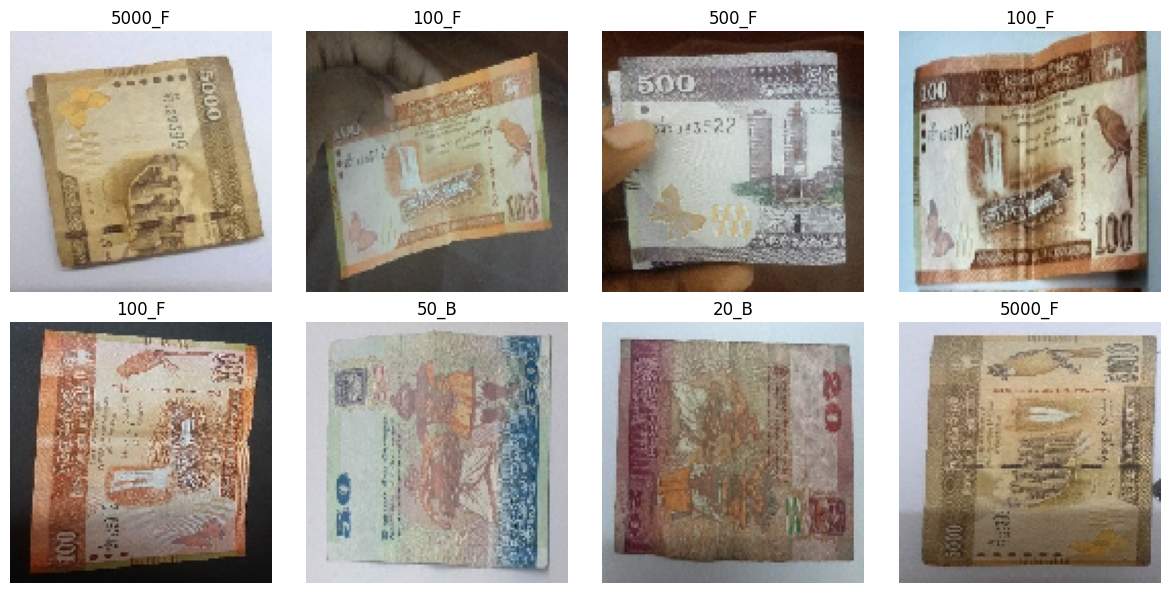

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     7,372,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,449,292 (28.42 MB)

 Trainable params: 7,449,292 (28.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.1084 - loss: 3.4988 - val_accuracy: 0.2482 - val_loss: 2.3231
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3118 - loss: 2.1119 - val_accuracy: 0.2872 - val_loss: 1.9834
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.5082 - loss: 1.4573 - val_accuracy: 0.4007 - val_loss: 1.5967
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.7265 - loss: 0.8513 - val_accuracy: 0.5106 - val_loss: 1.4081
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8528 - loss: 0.4748 - val_accuracy: 0.6738 - val_loss: 1.1340


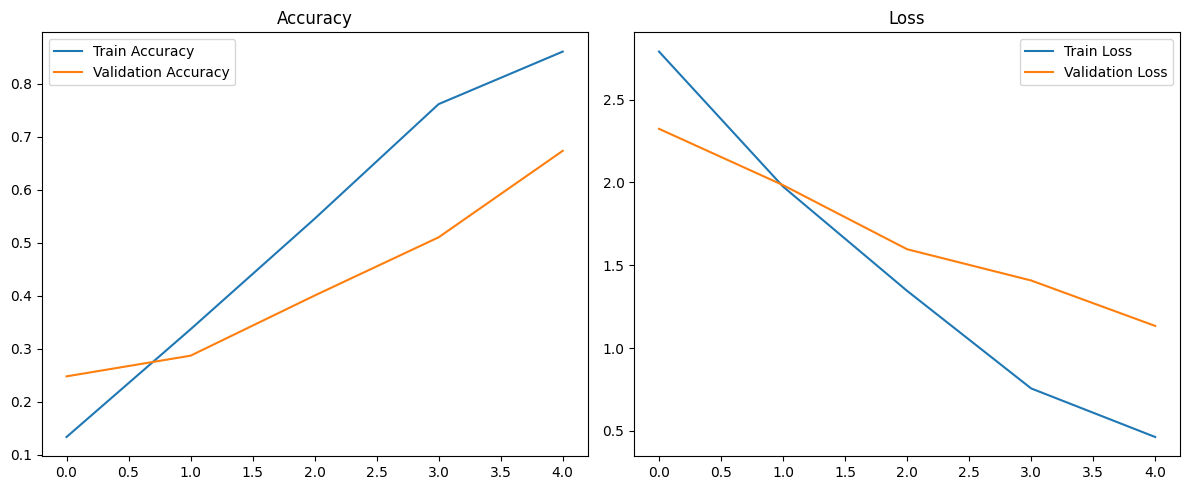

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8589 - loss: 0.5272

Test Accuracy: 0.8722958564758301
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


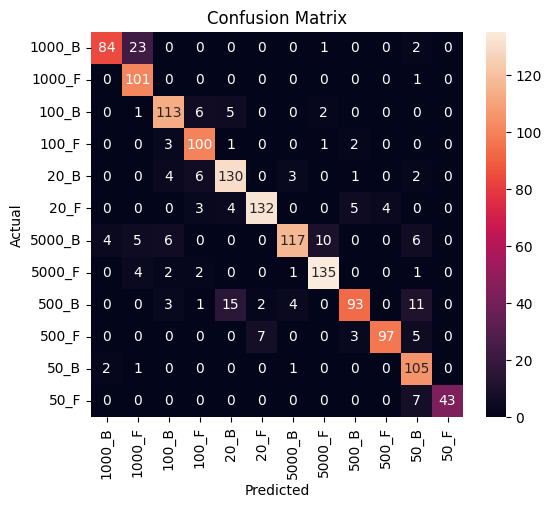


Classification Report:
              precision    recall  f1-score   support

      1000_B       0.93      0.76      0.84       110
      1000_F       0.75      0.99      0.85       102
       100_B       0.86      0.89      0.88       127
       100_F       0.85      0.93      0.89       107
        20_B       0.84      0.89      0.86       146
        20_F       0.94      0.89      0.91       148
      5000_B       0.93      0.79      0.85       148
      5000_F       0.91      0.93      0.92       145
       500_B       0.89      0.72      0.80       129
       500_F       0.96      0.87      0.91       112
        50_B       0.75      0.96      0.84       109
        50_F       1.00      0.86      0.92        50

    accuracy                           0.87      1433
   macro avg       0.88      0.87      0.87      1433
weighted avg       0.88      0.87      0.87      1433

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


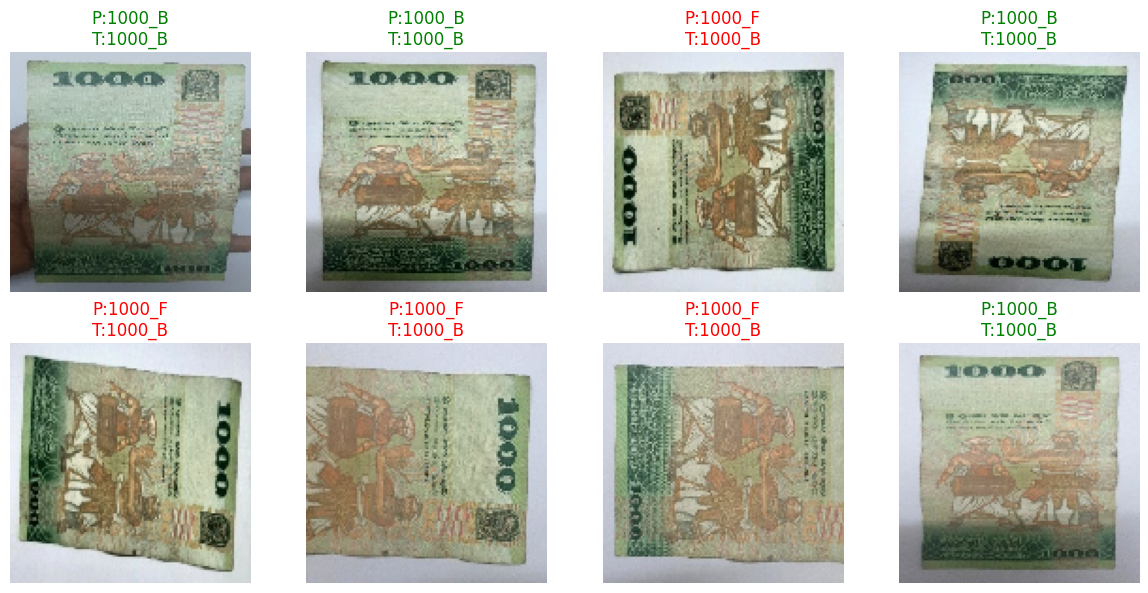

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

train_dir = "/content/Dataset"
test_dir = "/content/Dataset"

img_size = 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of Classes:", num_classes)

images, labels = next(train_generator)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

model = keras.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print("\nTest Accuracy:", test_accuracy)

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

images, labels = next(test_generator)

preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    color = "green" if pred_classes[i]==true_classes[i] else "red"
    plt.title(f"P:{class_names[pred_classes[i]]}\nT:{class_names[true_classes[i]]}",
              color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

model.save("/content/money_model_v1.h5")

Saving images (3).jfif to images (3) (2).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


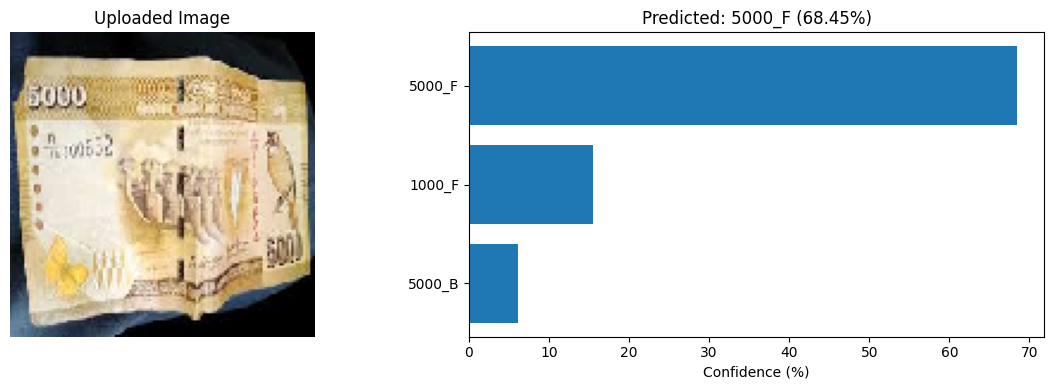


Top 3 Predictions:

5000_F : 68.45%
1000_F : 15.53%
5000_B : 6.14%


In [32]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image():
    uploaded = files.upload()

    input_size = model.input_shape[1]

    for fn in uploaded.keys():
        img = image.load_img(fn, target_size=(input_size, input_size))
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        probabilities = predictions[0]


        top_3_indices = np.argsort(probabilities)[-3:][::-1]
        top_3_probs = probabilities[top_3_indices] * 100
        top_3_labels = [class_names[i] for i in top_3_indices]

        predicted_class = top_3_labels[0]
        confidence = top_3_probs[0]


        plt.figure(figsize=(12,4))


        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title("Uploaded Image")
        plt.axis("off")


        plt.subplot(1,2,2)
        plt.barh(top_3_labels[::-1], top_3_probs[::-1])
        plt.xlabel("Confidence (%)")
        plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")

        plt.tight_layout()
        plt.show()

        print("\nTop 3 Predictions:\n")
        for label, prob in zip(top_3_labels, top_3_probs):
            print(f"{label} : {prob:.2f}%")

predict_uploaded_image()